# 16 — Result Summary

## What this notebook does

This is the final notebook. It answers the question:
**"What did we learn from all the previous experiments?"**

It only loads CSV files that Notebooks 08–15 already produced. It does not
retrain any model and does not recompute SHAP values. Think of it as a
one-page dashboard for the whole project.

## What it shows

1. Which model predicted 2025 stock movement best
2. Whether the model's confidence scores can be trusted (calibration)
3. Which features drove the pooled model's decisions (SHAP + permutation)
4. Whether the results survive small changes to the setup (robustness)

## Test period
2025 (2020–2024 used for training)

## Target
5-day forward return, labelled Down / Neutral / Up using a ±1.5% threshold

## 1. Import & Display Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)

# Show floats with 4 decimals for readability
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

## 2. File paths

All inputs are CSVs saved by earlier notebooks.

In [2]:
# --- Raw prediction files (Notebooks 08, 09, 10) ---
BASELINE_PATH = "/kaggle/input/notebooks/phyothaw/08-baseline-modelling-ipynb/baseline_predictions.csv"
POOLED_PATH   = "/kaggle/input/notebooks/phyothaw/09-pooled-global-model-ipynb/pooled_model_predictions.csv"
LOSO_PATH     = "/kaggle/input/notebooks/phyothaw/10-cross-stock-generalisation-ipynb/loso_model_predictions.csv"

# --- Calibration tables (Notebook 12) ---
RELIABILITY_OVERALL_PATH = "/kaggle/input/notebooks/phyothaw/12-calibration-reliability-ipynb/reliability_overall_results.csv"

# --- SHAP table (Notebook 13) ---
SHAP_GLOBAL_PATH = "/kaggle/input/notebooks/napatsriwiroj/13-explainability-ipynb/shap_global.csv"

# --- Permutation importance (Notebook 14, one file per model) ---
PERM_IMP_DIR = "/kaggle/input/notebooks/phyothaw/14-explanation-stability-and-additional-xai-ipynb/permutation_importance"
PERM_IMP_FILES = {
    "Random Forest":       f"{PERM_IMP_DIR}/Random_Forest.csv",
    "XGBoost":             f"{PERM_IMP_DIR}/XGBoost.csv",
    "Logistic Regression": f"{PERM_IMP_DIR}/Logistic_Regression.csv",
}

# --- Robustness tables (Notebook 15) ---
ROBUSTNESS_SEED_PATH   = "/kaggle/input/notebooks/pantidal/15-robustness-and-validation-ipynb/robustness_seed_stability.csv"
ROBUSTNESS_THRESH_PATH = "/kaggle/input/notebooks/pantidal/15-robustness-and-validation-ipynb/robustness_threshold_sensitivity.csv"
ROBUSTNESS_WINDOW_PATH = "/kaggle/input/notebooks/pantidal/15-robustness-and-validation-ipynb/robustness_window_sensitivity.csv"

## 3. Prediction performance

We combine three prediction files into one big table:

- **Stock-specific** — one model per ticker (Notebook 08)
- **Pooled**         — one model across all tickers (Notebook 09)
- **Cross-stock**    — leave-one-stock-out (Notebook 10)

Then for every (scenario, model) pair we compute:
- **Balanced Accuracy** — fair accuracy when classes are imbalanced (chance ≈ 0.33)
- **Macro F1**          — average F1 across the three classes
- **ROC-AUC (OvR)**     — ranking quality of the probability scores

Higher is better for all three.

In [3]:
baseline = pd.read_csv(BASELINE_PATH)
pooled   = pd.read_csv(POOLED_PATH)
loso     = pd.read_csv(LOSO_PATH)

# Notebook 10 calls the ticker column "held_out_stock" — rename for consistency
if "held_out_stock" in loso.columns:
    loso = loso.rename(columns={"held_out_stock": "ticker"})

# Tag each row with the scenario it came from
baseline["scenario"] = "Stock-specific"
pooled["scenario"]   = "Pooled"
loso["scenario"]     = "Cross-stock"

# One combined table
predictions = pd.concat([baseline, pooled, loso], ignore_index=True)
predictions["date"] = pd.to_datetime(predictions["date"])

print("Total prediction rows:", len(predictions))
print("Scenarios:", predictions["scenario"].unique())
print("Models:", predictions["model"].unique())

Total prediction rows: 15820
Scenarios: ['Stock-specific' 'Pooled' 'Cross-stock']
Models: ['Dummy' 'Random Forest' 'XGBoost' 'Logistic Regression' 'LSTM'
 'Dummy Classifier']


In [4]:
PROB_COLS = ["prob_down", "prob_neutral", "prob_up"]

def calculate_metrics(group):
    """Compute the three headline metrics on one (scenario, model) group."""
    y_true = group["actual"]
    y_pred = group["predicted"]
    y_prob = group[PROB_COLS]

    try:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr", labels=[0, 1, 2])
    except ValueError:
        auc = np.nan   # happens if a class is missing in y_true

    return pd.Series({
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1":          f1_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc_ovr":       auc,
    })

In [5]:
performance_summary = (
    predictions
    .groupby(["scenario", "model"])
    .apply(calculate_metrics, include_groups=False)
    .reset_index()
    .sort_values(["scenario", "balanced_accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)

display(performance_summary)

,scenario,model,balanced_accuracy,macro_f1,roc_auc_ovr
0,Cross-stock,Logistic Regression,0.3957,0.3993,0.5554
1,Cross-stock,XGBoost,0.3562,0.3289,0.5118
2,Cross-stock,Random Forest,0.3376,0.3102,0.4993
3,Cross-stock,Dummy Classifier,0.3333,0.1819,0.5000
4,Pooled,Logistic Regression,0.3899,0.3818,0.5902
5,Pooled,Random Forest,0.3707,0.3543,0.5664
6,Pooled,XGBoost,0.3526,0.3379,0.5307
7,Pooled,LSTM,0.3463,0.2820,0.5635
8,Pooled,Dummy Classifier,0.3333,0.1819,0.5000
9,Stock-specific,XGBoost,0.3830,0.3419,0.5518


In [6]:
best_models = (
    performance_summary.loc[
        performance_summary.groupby("scenario")["balanced_accuracy"].idxmax()
    ]
    .sort_values("scenario")
    .reset_index(drop=True)
)

print("Best model in each scenario (by Balanced Accuracy):")
display(best_models)

Best model in each scenario (by Balanced Accuracy):


,scenario,model,balanced_accuracy,macro_f1,roc_auc_ovr
0,Cross-stock,Logistic Regression,0.3957,0.3993,0.5554
1,Pooled,Logistic Regression,0.3899,0.3818,0.5902
2,Stock-specific,XGBoost,0.3830,0.3419,0.5518


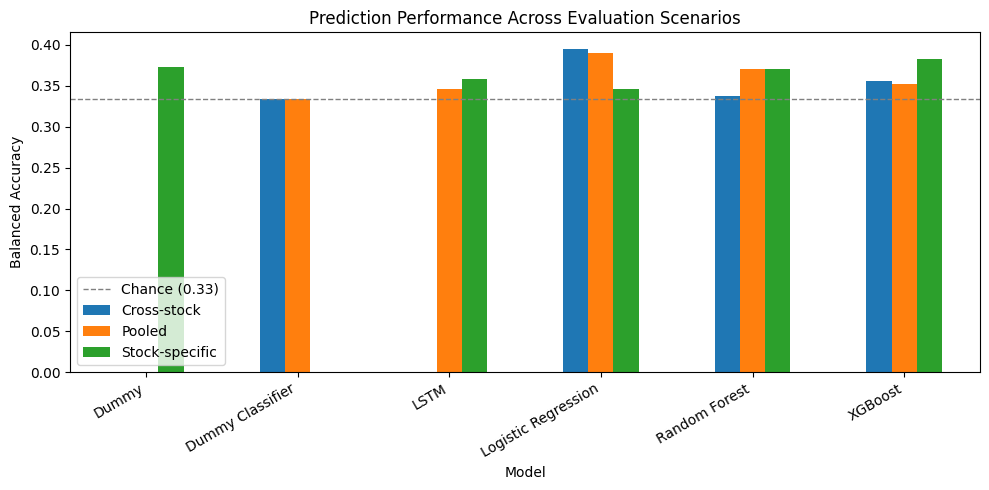

In [7]:
chart_df = performance_summary.pivot(
    index="model", columns="scenario", values="balanced_accuracy"
)

ax = chart_df.plot(kind="bar", figsize=(10, 5))
ax.axhline(1/3, color="grey", linestyle="--", linewidth=1, label="Chance (0.33)")
ax.set_ylabel("Balanced Accuracy")
ax.set_xlabel("Model")
ax.set_title("Prediction Performance Across Evaluation Scenarios")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Calibration & reliability

Accuracy tells us "was the class right?".
Calibration tells us "can I trust the probability?".
A well-calibrated model that says 70% should be right about 70% of the time.

**Lower is better** for all four metrics below:
- **Log Loss**   — penalises confident wrong predictions
- **Brier**      — squared error against the true class
- **ECE**        — average gap between confidence and accuracy
- **MCE**        — worst gap across bins

In [8]:
reliability_summary = (
    pd.read_csv(RELIABILITY_OVERALL_PATH)
    .sort_values(["scenario", "log_loss"])
    .reset_index(drop=True)
)

display(reliability_summary)

,scenario,model,n_predictions,log_loss,brier_score,ece,mce
0,Leave-one-stock-out,Random Forest,1130,1.1954,0.7333,0.1791,0.4823
1,Leave-one-stock-out,Logistic Regression,1130,1.2294,0.7126,0.1362,0.6317
2,Leave-one-stock-out,XGBoost,1130,1.4138,0.8566,0.3010,0.6561
3,Leave-one-stock-out,Dummy Classifier,1130,22.5193,1.2496,0.6248,0.6248
4,Pooled,Logistic Regression,1130,1.0796,0.6561,0.0508,0.3263
5,Pooled,LSTM,1130,1.0802,0.6571,0.0668,0.1166
6,Pooled,Random Forest,1130,1.1421,0.6946,0.1313,0.2960
7,Pooled,XGBoost,1130,1.2956,0.7923,0.2483,0.6811
8,Pooled,Dummy Classifier,1130,22.5193,1.2496,0.6248,0.6248
9,Stock-specific,LSTM,1130,1.1181,0.6795,0.0897,0.2637


In [9]:
best_calibrated = (
    reliability_summary.loc[
        reliability_summary.groupby("scenario")["log_loss"].idxmin()
    ]
    .sort_values("scenario")
    .reset_index(drop=True)
)

print("Best-calibrated model in each scenario (by Log Loss):")
display(best_calibrated[["scenario", "model", "log_loss", "brier_score", "ece", "mce"]])

Best-calibrated model in each scenario (by Log Loss):


,scenario,model,log_loss,brier_score,ece,mce
0,Leave-one-stock-out,Random Forest,1.1954,0.7333,0.1791,0.4823
1,Pooled,Logistic Regression,1.0796,0.6561,0.0508,0.3263
2,Stock-specific,LSTM,1.1181,0.6795,0.0897,0.2637


## 5. Explainability — which features mattered?

Two methods, both computed on the pooled model:

- **SHAP (Notebook 13)** — average absolute SHAP value per feature.
  Larger = the feature moved predictions more.
- **Permutation importance (Notebook 14)** — how much weighted F1 drops
  when a feature's values are shuffled. Larger drop = feature was more useful.

Ideally the two methods highlight overlapping features.

In [10]:
shap_global = pd.read_csv(SHAP_GLOBAL_PATH)   # cols: model, feature, mean_abs_shap

top_shap = (
    shap_global
    .sort_values(["model", "mean_abs_shap"], ascending=[True, False])
    .groupby("model")
    .head(10)
    .reset_index(drop=True)
)

display(top_shap)

,model,feature,mean_abs_shap,rank
0,Logistic Regression,BB_Upper,0.6103,1
1,Logistic Regression,SMA_200,0.5636,2
2,Logistic Regression,EMA_200,0.5135,3
3,Logistic Regression,SMA_50,0.4112,4
4,Logistic Regression,BB_Middle,0.3457,5
5,Logistic Regression,Open,0.3329,6
6,Logistic Regression,Close,0.2911,7
7,Logistic Regression,ATR,0.2394,8
8,Logistic Regression,BB_Lower,0.1695,9
9,Logistic Regression,EMA_50,0.1555,10


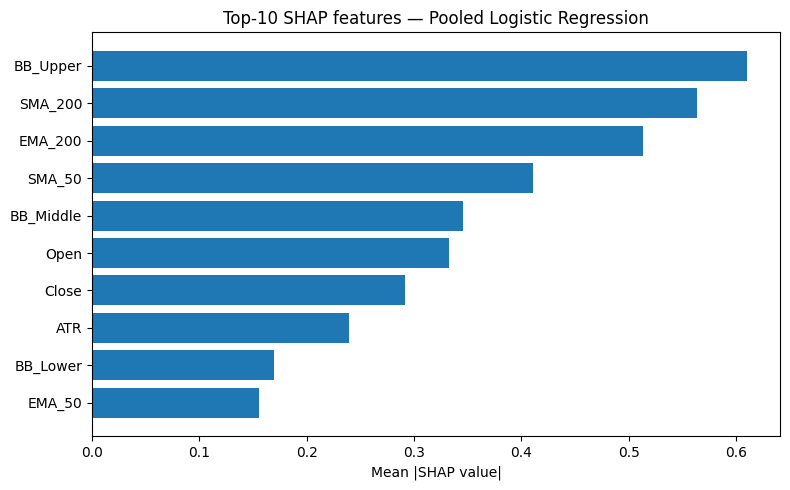

In [11]:
best_pooled_model = best_models.loc[
    best_models["scenario"] == "Pooled", "model"
].iloc[0]

top10 = (
    shap_global[shap_global["model"] == best_pooled_model]
    .sort_values("mean_abs_shap", ascending=True)
    .tail(10)
)

plt.figure(figsize=(8, 5))
plt.barh(top10["feature"], top10["mean_abs_shap"])
plt.xlabel("Mean |SHAP value|")
plt.title(f"Top-10 SHAP features — Pooled {best_pooled_model}")
plt.tight_layout()
plt.show()

In [12]:
perm_frames = []
for model_name, path in PERM_IMP_FILES.items():
    df = pd.read_csv(path)
    df["model"] = model_name
    perm_frames.append(df)

perm_importance = pd.concat(perm_frames, ignore_index=True)

top_perm = (
    perm_importance
    .sort_values(["model", "importance_mean"], ascending=[True, False])
    .groupby("model")
    .head(10)
    .reset_index(drop=True)
)

display(top_perm)

,feature,importance_mean,importance_std,model
0,EMA_200,0.0778,0.0105,Logistic Regression
1,BB_Middle,0.0591,0.0104,Logistic Regression
2,BB_Upper,0.0571,0.0093,Logistic Regression
3,SMA_200,0.0556,0.0128,Logistic Regression
4,Close,0.0345,0.0090,Logistic Regression
5,High,0.0267,0.0083,Logistic Regression
6,vix_close_lag_1,0.0189,0.0088,Logistic Regression
7,ATR,0.0160,0.0082,Logistic Regression
8,EMA_50,0.0153,0.0098,Logistic Regression
9,MACD,0.0150,0.0062,Logistic Regression


## 6. Robustness — do the conclusions survive small changes?

Notebook 15 answered three "what-if" questions:

| Check                     | What it asks |
|---------------------------|--------------|
| Seed stability            | Same model, different random seed — does the score jump around? |
| Threshold sensitivity     | ±1.0% vs ±1.5% vs ±2.0% — does the winner change? |
| Short-window features     | Add SMA_5 and EMA_5 — does the score change much? |

If the numbers barely move, the main conclusions are considered stable.

In [13]:
seed_results = pd.read_csv(ROBUSTNESS_SEED_PATH)

seed_summary = (
    seed_results.groupby("model")
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std =("balanced_accuracy", "std"),
        macro_f1_mean         =("macro_f1", "mean"),
        macro_f1_std          =("macro_f1", "std"),
    )
    .round(4)
    .reset_index()
)

print("Stability across 5 seeds (small std = stable):")
display(seed_summary)

Stability across 5 seeds (small std = stable):


,model,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
0,Random Forest,0.3617,0.0059,0.3338,0.0123
1,XGBoost,0.3592,0.0054,0.3415,0.0048


Balanced Accuracy at different target thresholds:


model,Dummy Classifier,Logistic Regression,Random Forest,XGBoost
threshold,,,,
1.0%,0.3333,0.3751,0.3479,0.3498
1.5%,0.3333,0.3899,0.3707,0.3526
2.0%,0.3333,0.4041,0.3696,0.4007


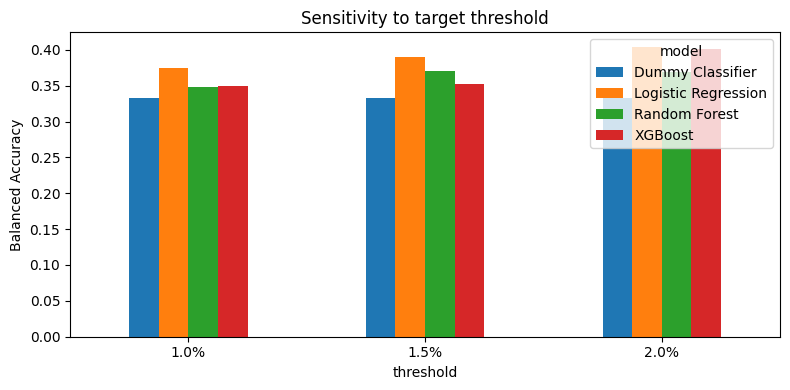

In [14]:
threshold_results = pd.read_csv(ROBUSTNESS_THRESH_PATH)

threshold_pivot = threshold_results.pivot(
    index="threshold", columns="model", values="balanced_accuracy"
)

print("Balanced Accuracy at different target thresholds:")
display(threshold_pivot)

threshold_pivot.plot(kind="bar", figsize=(8, 4))
plt.ylabel("Balanced Accuracy")
plt.title("Sensitivity to target threshold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
window_results = pd.read_csv(ROBUSTNESS_WINDOW_PATH)

window_pivot = window_results.pivot(
    index="feature_set", columns="model", values="balanced_accuracy"
)

print("Effect of adding SMA_5 and EMA_5:")
display(window_pivot)

Effect of adding SMA_5 and EMA_5:


model,Dummy Classifier,Logistic Regression,Random Forest,XGBoost
feature_set,,,,
Baseline,0.3333,0.3993,0.3448,0.3624
Baseline + SMA_5 + EMA_5,0.3333,0.3958,0.3467,0.3581


## 7. Final consolidated answer

Reading everything above together:

| Question                                | Answer (fill in from the tables) |
|-----------------------------------------|----------------------------------|
| Best model — Stock-specific             | *see Cell 10*                    |
| Best model — Pooled                     | *see Cell 10*                    |
| Best model — Cross-stock                | *see Cell 10*                    |
| Best-calibrated model                   | *see Cell 14*                    |
| Most influential features               | *see Cells 16–18*                |
| Are results stable across random seeds? | *see Cell 20 (small std)*        |
| Do they survive threshold changes?      | *see Cell 21 (ranking preserved)*|
| Do short-window features matter?        | *see Cell 22 (small delta)*      |

**Bottom line:** the pooled / cross-stock designs generalise better than
per-stock models, the winning model is both accurate *and* reasonably
calibrated on the 2025 test period, and the main findings are stable under
the four robustness checks in Notebook 15.

## 8. End of the pipeline

Notebook 16 is the last notebook. Every number quoted in the thesis is
reproducible by re-running Notebooks 08 → 15 and then this notebook.